In [1]:
# %%
# ruff: noqa: T201
"""Benchmark evaluating the isolated effect of the 2c threshold in LeverageSHAP.

The comparison includes:
1. KernelSHAP (Standard Control)
2. LeverageSHAP (Without 2c Limit) - Leverage score weights, but uniform budget allocation
3. LeverageSHAP (Full Custom) - Optimal 2c-based Bernoulli thresholding
"""

from __future__ import annotations

import math
import random as _py_random
import warnings
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb
from scipy.stats import wilcoxon
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

from shapiq import KernelSHAP
from shapiq.approximator.regression.leverageshap import LeverageSHAP
from shapiq.approximator.sampling import CoalitionSampler
from shapiq.interaction_values import InteractionValues

warnings.filterwarnings("ignore")

In [2]:
# %%
# ── LeverageSHAP Variant without the 2c Threshold Limit ───────────────
class LeverageSHAPWithout2c(LeverageSHAP):
    """LeverageSHAP variant that bypasses the 2c oversampling and threshold boundaries.

    This class overrides the sampling method to demonstrate the impact of omitting
    the optimal boundary thresholding from the algorithm.
    """

    def _sample(self, budget: int) -> tuple[np.ndarray, np.ndarray]:
        if budget < 2:
            msg = "Budget must be at least 2 to evaluate baseline and grand coalition."
            raise ValueError(msg)

        n = self.n
        m = min(budget, 2**n)

        z_empty = np.zeros(n, dtype=bool)
        z_grand = np.ones(n, dtype=bool)

        # -----------------------------------------------------------------
        # - OMITTED: Finding the optimal oversampling parameter `c` via binary search
        # - c = self._find_c(n, m)
        # -----------------------------------------------------------------
        # + ADDED INSTEAD:
        # + Without the parameter `c`, a flat allocation is applied to distribute
        # + the total pair budget (m - 2) // 2 evenly across all possible size layers s.
        # -----------------------------------------------------------------
        n_pairs_target = (m - 2) // 2
        sizes_to_sample = list(range(1, n // 2 + 1))
        num_sizes = len(sizes_to_sample)

        pairs_per_size = n_pairs_target // num_sizes if num_sizes > 0 else 0
        remainder = n_pairs_target % num_sizes if num_sizes > 0 else 0

        z_list: list[np.ndarray] = []
        sizes_list: list[int] = []

        py_seed = int(self._rng.integers(0, 2**32))
        py_rng = _py_random.Random(py_seed)

        for idx_size, s in enumerate(sizes_to_sample):
            is_middle = (n % 2 == 0) and (s == n // 2)
            full_count = math.comb(n, s)
            pool_size = math.comb(n - 1, s - 1) if is_middle else full_count

            # Determine target pair budget for this size layer
            m_s_target = pairs_per_size + (1 if idx_size < remainder else 0)
            m_s = min(m_s_target, pool_size)

            # -----------------------------------------------------------------
            # - OMITTED: Bernoulli sampling using 2c-based probability and thresholding
            # - Z_pairs, sizes = self._bernoulli_sample(n, c)
            # - (Which caps smaller sizes at prob = 1.0 and samples larger sizes with prob = 2c / full_count)
            # -----------------------------------------------------------------
            # + ADDED INSTEAD:
            # + We bypass the binomial probabilistic assignment and sample exactly `m_s`
            # + unique coalitions directly without threshold limits.
            # -----------------------------------------------------------------
            indices = self._sample_without_replacement(pool_size, m_s, py_rng)

            for idx in indices:
                if is_middle:
                    z_partial = self._combo(n - 1, s - 1, idx)
                    z = np.zeros(n, dtype=bool)
                    z[: n - 1] = z_partial
                    z[n - 1] = True
                else:
                    z = self._combo(n, s, idx)
                z_bar = ~z
                z_list.append(z)
                z_list.append(z_bar)
                sizes_list.append(s)
                sizes_list.append(n - s)

        if len(z_list) > 0:
            Z_pairs = np.array(z_list)
            sizes = np.array(sizes_list)
            weights_pairs = np.empty(Z_pairs.shape[0], dtype=float)
            fact_n = math.factorial(n)

            for i, s in enumerate(sizes):
                w_s = (math.factorial(s - 1) * math.factorial(n - s - 1)) / fact_n

                # -----------------------------------------------------------------
                # - OMITTED: Importance sampling reweighting using 2c and leverage score
                # - l_z = 1.0 / math.comb(n, s)
                # - p = min(1.0, 2.0 * c * l_z)
                # - weights_pairs[i] = w_s / p
                # -----------------------------------------------------------------
                # + ADDED INSTEAD:
                # + Without `c`, we use the actual sampling probability of drawing
                # + a specific coalition in this size layer: p = m_s / pool_size.
                # + This maintains the weight-cancellation property of the leverage scores
                # + but does not use the optimal planning constant `c`.
                # -----------------------------------------------------------------
                s_paired = min(s, n - s)
                is_middle_s = (n % 2 == 0) and (s_paired == n // 2)
                pool_s = math.comb(n - 1, s_paired - 1) if is_middle_s else math.comb(n, s_paired)

                idx_in_loop = sizes_to_sample.index(s_paired)
                m_s_drawn = pairs_per_size + (1 if idx_in_loop < remainder else 0)
                m_s_drawn = min(m_s_drawn, pool_s)

                p_s_actual = m_s_drawn / pool_s if pool_s > 0 else 1.0
                if p_s_actual <= 0:
                    p_s_actual = 1.0

                weights_pairs[i] = w_s / p_s_actual

            Z = np.vstack([z_empty[None, :], z_grand[None, :], Z_pairs])
            weights = np.concatenate([[0.0, 0.0], weights_pairs])
        else:
            Z = np.vstack([z_empty[None, :], z_grand[None, :]])
            weights = np.array([0.0, 0.0])

        return Z, weights


class LeverageSHAPWoBernoulli(LeverageSHAP):
    """LeverageSHAP using the standard CoalitionSampler instead of Algorithm 2."""

    def __init__(
        self, n: int, *, pairing_trick: bool = True, random_state: int | None = None, **kwargs: Any
    ) -> None:
        """Initialize the class override for benchmarking."""
        self._explicit_seed = random_state
        super().__init__(n=n, pairing_trick=pairing_trick, random_state=random_state, **kwargs)

    def _sample(self, budget: int) -> tuple[np.ndarray, np.ndarray]:
        sampler = CoalitionSampler(
            n_players=self.n,
            sampling_weights=np.ones(self.n + 1),
            pairing_trick=True,
            random_state=self._explicit_seed,
        )

        sampler.sample(budget)
        Z = sampler.coalitions_matrix
        is_weights = sampler.sampling_adjustment_weights

        weights = np.zeros_like(is_weights)
        fact_n = math.factorial(self.n)
        sizes = Z.sum(axis=1)

        for i, s in enumerate(sizes):
            if 0 < s < self.n:
                w_s = (math.factorial(s - 1) * math.factorial(self.n - s - 1)) / fact_n
                weights[i] = is_weights[i] * w_s

        return Z, weights

In [3]:
# %%
# ── Metrics & Extraction Helpers ──────────────────────────────────────
def norm_l2(exact: np.ndarray, approx: np.ndarray) -> float:
    """Normalized ℓ₂ error: ‖exact − approx‖₂ / ‖exact‖₂."""
    denom = np.linalg.norm(exact)
    return 0.0 if denom < 1e-12 else float(np.linalg.norm(exact - approx) / denom)


def extract_sv(iv: InteractionValues, n: int) -> np.ndarray:
    """Extract Shapley vector of length n from an IV mapping."""
    return np.array([iv[(i,)] for i in range(n)])

In [4]:
# %%
# ── Setup California Dataset (n=8) ────────────────────────────────────
X, y = fetch_california_housing(return_X_y=True)
n_players = 8

X_train, X_test, y_train, _ = train_test_split(X[:, :n_players], y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(n_estimators=100, max_depth=4, random_state=42, verbosity=0)
model.fit(X_train, y_train)

bg_mean = X_train.mean(axis=0)
x_instance = X_test[0]


def game(Z: np.ndarray) -> np.ndarray:
    """Mean-substitution game."""
    X_masked = np.where(Z, x_instance[np.newaxis, :], bg_mean[np.newaxis, :])
    return model.predict(X_masked)

In [5]:
# %%
# ── Run the Benchmark ─────────────────────────────────────────────────
n_runs = 50
budgets = np.linspace(10, 150, 15, dtype=int).tolist()

errs_ks = np.zeros((n_runs, len(budgets)))
errs_lev_no_2c = np.zeros((n_runs, len(budgets)))
errs_lev_full = np.zeros((n_runs, len(budgets)))
errs_lev_wo_bernoulli = np.zeros((n_runs, len(budgets)))

# Ground Truth Exact values
ks_exact = KernelSHAP(n=n_players, random_state=0)
iv_exact = ks_exact.approximate(2**n_players, game)
exact_sv = extract_sv(iv_exact, n_players)

print("Starting benchmark calculation...")
for i, budget in enumerate(budgets):
    for seed in range(n_runs):
        # 1. KernelSHAP (Control)
        ks = KernelSHAP(n=n_players, random_state=seed)
        errs_ks[seed, i] = norm_l2(exact_sv, extract_sv(ks.approximate(budget, game), n_players))

        # 2. LeverageSHAP without the 2c limit
        lev_no_2c = LeverageSHAPWithout2c(n=n_players, random_state=seed)
        errs_lev_no_2c[seed, i] = norm_l2(
            exact_sv, extract_sv(lev_no_2c.approximate(budget, game), n_players)
        )

        # 3. Full Custom LeverageSHAP (with 2c)
        lev_full = LeverageSHAP(n=n_players, random_state=seed)
        errs_lev_full[seed, i] = norm_l2(
            exact_sv, extract_sv(lev_full.approximate(budget, game), n_players)
        )

        # 4. LeverageSHAPWoBernoulli
        lev_wo_bernoulli = LeverageSHAPWoBernoulli(n=n_players, random_state=seed)
        errs_lev_wo_bernoulli[seed, i] = norm_l2(
            exact_sv, extract_sv(lev_wo_bernoulli.approximate(budget, game), n_players)
        )

Starting benchmark calculation...


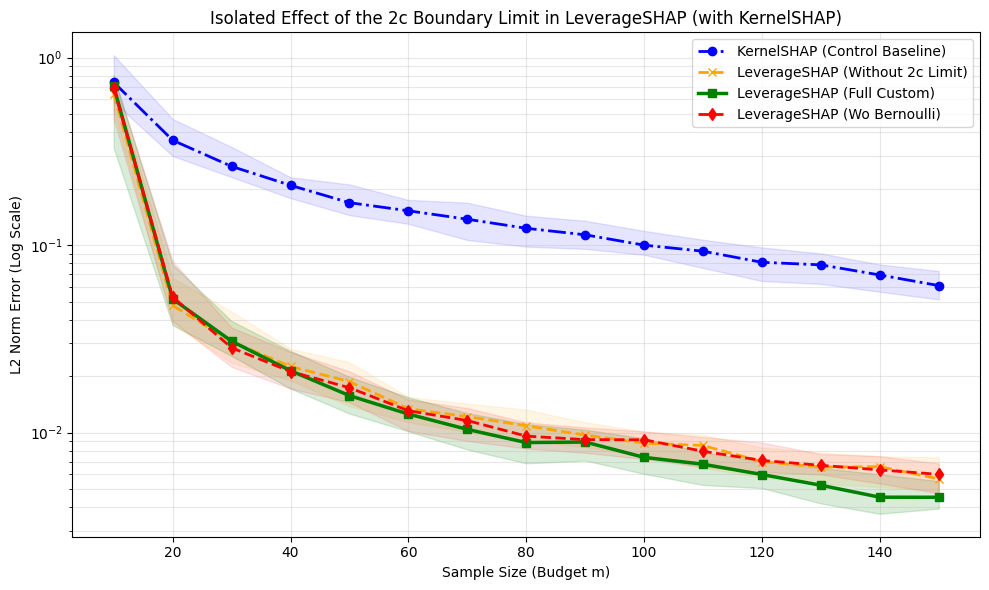

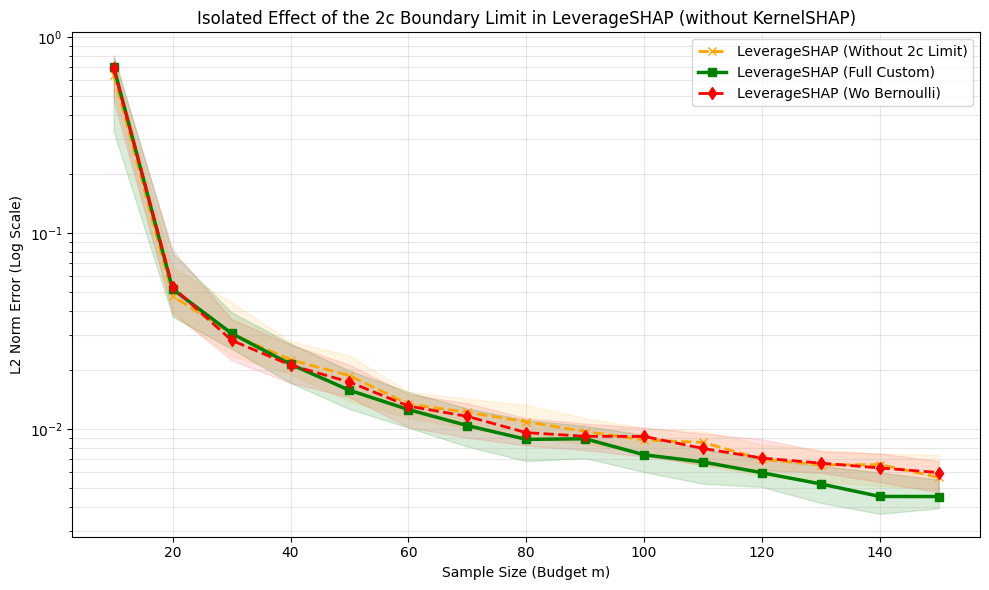

In [6]:
# %%
# ── Plotting Helper ───────────────────────────────────────────────────
def plot_results(plot_kernel: bool = False) -> None:
    plt.figure(figsize=(10, 6))

    if plot_kernel:
        plt.semilogy(
            budgets,
            np.median(errs_ks, axis=0),
            "o-.",
            label="KernelSHAP (Control Baseline)",
            color="blue",
            linewidth=2,
        )

    plt.semilogy(
        budgets,
        np.median(errs_lev_no_2c, axis=0),
        "x--",
        label="LeverageSHAP (Without 2c Limit)",
        color="orange",
        linewidth=2,
    )

    plt.semilogy(
        budgets,
        np.median(errs_lev_full, axis=0),
        "s-",
        label="LeverageSHAP (Full Custom)",
        color="green",
        linewidth=2.5,
    )

    plt.semilogy(
        budgets,
        np.median(errs_lev_wo_bernoulli, axis=0),
        "d--",
        label="LeverageSHAP (Wo Bernoulli)",
        color="red",
        linewidth=2,
    )

    # Fill Quantiles
    if plot_kernel:
        plt.fill_between(
            budgets,
            np.percentile(errs_ks, 25, axis=0),
            np.percentile(errs_ks, 75, axis=0),
            alpha=0.1,
            color="blue",
        )

    plt.fill_between(
        budgets,
        np.percentile(errs_lev_no_2c, 25, axis=0),
        np.percentile(errs_lev_no_2c, 75, axis=0),
        alpha=0.1,
        color="orange",
    )
    plt.fill_between(
        budgets,
        np.percentile(errs_lev_full, 25, axis=0),
        np.percentile(errs_lev_full, 75, axis=0),
        alpha=0.15,
        color="green",
    )
    plt.fill_between(
        budgets,
        np.percentile(errs_lev_wo_bernoulli, 25, axis=0),
        np.percentile(errs_lev_wo_bernoulli, 75, axis=0),
        alpha=0.1,
        color="red",
    )

    plt.xlabel("Sample Size (Budget m)")
    plt.ylabel("L2 Norm Error (Log Scale)")
    plt.title(
        "Isolated Effect of the 2c Boundary Limit in LeverageSHAP"
        + (" (with KernelSHAP)" if plot_kernel else " (without KernelSHAP)")
    )
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()


# Run both variants
plot_results(plot_kernel=True)
plot_results(plot_kernel=False)

In [7]:
import pandas as pd

# Build per-instance table (each run x budget pair)
n_runs_, n_budgets_ = errs_lev_no_2c.shape

table = pd.DataFrame(
    {
        "run": np.repeat(np.arange(n_runs_), n_budgets_),
        "budget": np.tile(budgets, n_runs_),
        "err_ks": errs_ks.ravel(),
        "err_lev_no_2c": errs_lev_no_2c.ravel(),
        "err_lev_full": errs_lev_full.ravel(),
        "err_lev_wo_bernoulli": errs_lev_wo_bernoulli.ravel(),
    }
)

# Wins (lower error is better)
table["lev_full_wins_vs_no_2c"] = table["err_lev_full"] < table["err_lev_no_2c"]
table["lev_full_wins_vs_wo_bernoulli"] = table["err_lev_full"] < table["err_lev_wo_bernoulli"]
table["no_2c_wins_vs_wo_bernoulli"] = table["err_lev_no_2c"] < table["err_lev_wo_bernoulli"]

# Win margins (positive => left model is better)
table["margin_full_vs_no2c"] = table["err_lev_no_2c"] - table["err_lev_full"]
table["margin_full_vs_wo_bern"] = table["err_lev_wo_bernoulli"] - table["err_lev_full"]
table["margin_no2c_vs_wo_bern"] = table["err_lev_wo_bernoulli"] - table["err_lev_no_2c"]

print("=== Per-instance table (all run x budget entries) ===")
print(table.to_string(index=False))


# ── Budget-wise win rates AND paired significance ─────────────────────────────
# The 750 rows are NOT independent: the same 50 seeds recur across all 15 budgets and
# are shared by every method. Treating them as 750 independent Bernoulli trials would
# overstate precision. We therefore report a paired Wilcoxon signed-rank test *per
# budget* on the per-seed error differences (the 50 seeds are the paired units within a
# budget). "Sig." = p < 0.05 AND lower median error for lev_full.
def paired_wilcoxon(err_a: np.ndarray, err_b: np.ndarray) -> tuple[float, float]:
    """Return (median difference b - a, p-value) for a paired Wilcoxon test per column-slice."""
    diff = err_b - err_a  # positive => a (lev_full) is better
    if np.allclose(diff, 0.0):
        return 0.0, 1.0
    try:
        _, p = wilcoxon(diff)
    except ValueError:
        return float(np.median(diff)), 1.0
    return float(np.median(diff)), float(p)


sig_rows = []
for i, budget in enumerate(budgets):
    med_fn, p_fn = paired_wilcoxon(errs_lev_full[:, i], errs_lev_no_2c[:, i])
    med_fb, p_fb = paired_wilcoxon(errs_lev_full[:, i], errs_lev_wo_bernoulli[:, i])
    sig_rows.append(
        {
            "budget": budget,
            "p_full_vs_no2c": round(p_fn, 4),
            "full_better_no2c": bool(p_fn < 0.05 and med_fn > 0),
            "p_full_vs_wo_bern": round(p_fb, 4),
            "full_better_wo_bern": bool(p_fb < 0.05 and med_fb > 0),
        }
    )
sig_by_budget = pd.DataFrame(sig_rows)

# Budget-wise win summary (raw win counts, kept for context; see significance table above)
summary_by_budget = table.groupby("budget", as_index=False).agg(
    instances=("budget", "size"),
    lev_full_win_count=("lev_full_wins_vs_no_2c", "sum"),
    lev_full_vs_wo_bern_win_count=("lev_full_wins_vs_wo_bernoulli", "sum"),
    no_2c_win_count=("no_2c_wins_vs_wo_bernoulli", "sum"),
    median_err_lev_full=("err_lev_full", "median"),
    median_err_lev_no_2c=("err_lev_no_2c", "median"),
    median_err_lev_wo_bernoulli=("err_lev_wo_bernoulli", "median"),
)
summary_by_budget = summary_by_budget.merge(sig_by_budget, on="budget")

print("\n=== Paired Wilcoxon significance by budget (50 shared seeds per budget) ===")
print(sig_by_budget.to_string(index=False))

n_sig_full_no2c = int(sig_by_budget["full_better_no2c"].sum())
n_sig_full_wo_bern = int(sig_by_budget["full_better_wo_bern"].sum())
print(
    f"\nlev_full significantly better than lev_no_2c at {n_sig_full_no2c}/{len(budgets)} budgets; "
    f"than lev_wo_bernoulli at {n_sig_full_wo_bern}/{len(budgets)} budgets (p < 0.05, paired)."
)

# Overall paired test: pool the per-seed differences across budgets but respect pairing
# (each (seed, budget) difference is one paired observation).
overall_rows = []
for name, err_left, err_right in [
    ("lev_full vs lev_no_2c", errs_lev_full, errs_lev_no_2c),
    ("lev_full vs lev_wo_bernoulli", errs_lev_full, errs_lev_wo_bernoulli),
    ("lev_no_2c vs lev_wo_bernoulli", errs_lev_no_2c, errs_lev_wo_bernoulli),
]:
    diff = (err_right - err_left).ravel()  # positive => left is better
    try:
        _, p = wilcoxon(diff)
    except ValueError:
        p = 1.0
    overall_rows.append(
        {
            "comparison": name,
            "median_margin": round(float(np.median(diff)), 5),
            "p_value": f"{p:.2e}",
            "left_better": bool(p < 0.05 and np.median(diff) > 0),
        }
    )
overall = pd.DataFrame(overall_rows)

print("\n=== Overall paired Wilcoxon summary (positive margin => left model better) ===")
print(overall.to_string(index=False))

=== Per-instance table (all run x budget entries) ===
 run  budget       err_ks  err_lev_no_2c  err_lev_full  err_lev_wo_bernoulli  lev_full_wins_vs_no_2c  lev_full_wins_vs_wo_bernoulli  no_2c_wins_vs_wo_bernoulli  margin_full_vs_no2c  margin_full_vs_wo_bern  margin_no2c_vs_wo_bern
   0      10 9.387193e-01       0.701070      0.847305              0.791678                   False                          False                        True        -1.462345e-01               -0.055626            9.060822e-02
   0      20 4.137244e-01       0.038156      0.813323              0.093654                   False                          False                        True        -7.751674e-01               -0.719669            5.549824e-02
   0      30 1.849863e-01       0.045829      0.039031              0.041928                    True                           True                       False         6.798088e-03                0.002897           -3.900779e-03
   0      40 1.722260e-01     

In [8]:
table

,run,budget,err_ks,err_lev_no_2c,err_lev_full,err_lev_wo_bernoulli,lev_full_wins_vs_no_2c,lev_full_wins_vs_wo_bernoulli,no_2c_wins_vs_wo_bernoulli,margin_full_vs_no2c,margin_full_vs_wo_bern,margin_no2c_vs_wo_bern
0,0,10,0.938719,0.701070,0.847305,0.791678,False,False,True,-0.146235,-0.055626,0.090608
1,0,20,0.413724,0.038156,0.813323,0.093654,False,False,True,-0.775167,-0.719669,0.055498
2,0,30,0.184986,0.045829,0.039031,0.041928,True,True,False,0.006798,0.002897,-0.003901
3,0,40,0.172226,0.022148,0.021287,0.016682,True,False,False,0.000861,-0.004605,-0.005465
4,0,50,0.136241,0.019493,0.023753,0.015707,False,False,False,-0.004260,-0.008046,-0.003786
...,...,...,...,...,...,...,...,...,...,...,...,...
745,49,110,0.074878,0.011275,0.008626,0.010707,True,True,False,0.002649,0.002081,-0.000568
746,49,120,0.068338,0.007898,0.005860,0.009476,True,True,True,0.002038,0.003616,0.001577
747,49,130,0.073435,0.007822,0.003975,0.009487,True,True,True,0.003847,0.005511,0.001665
748,49,140,0.078557,0.007270,0.006208,0.009647,True,True,True,0.001062,0.003438,0.002377


In [9]:
summary_by_budget

,budget,instances,lev_full_win_count,lev_full_vs_wo_bern_win_count,no_2c_win_count,median_err_lev_full,median_err_lev_no_2c,median_err_lev_wo_bernoulli,p_full_vs_no2c,full_better_no2c,p_full_vs_wo_bern,full_better_wo_bern
0,10,50,22,20,28,0.702597,0.641882,0.691045,0.3137,False,0.6322,False
1,20,50,26,27,27,0.051634,0.047657,0.052910,0.7304,False,0.8859,False
2,30,50,27,26,21,0.030713,0.030558,0.028327,0.3572,False,0.4964,False
3,40,50,26,25,22,0.021386,0.022517,0.021159,0.5656,False,0.9314,False
4,50,50,30,31,19,0.015743,0.018711,0.017346,0.1781,False,0.1750,False
5,60,50,29,23,23,0.012553,0.013394,0.013079,0.2115,False,0.8333,False
6,70,50,35,30,21,0.010398,0.012166,0.011589,0.0018,True,0.3572,False
7,80,50,33,32,18,0.008844,0.010874,0.009573,0.0078,True,0.4097,False
8,90,50,30,28,22,0.008905,0.009699,0.009171,0.0429,True,0.3777,False
9,100,50,32,33,22,0.007377,0.008782,0.009153,0.0255,True,0.0109,True


In [10]:
overall

,comparison,median_margin,p_value,left_better
0,lev_full vs lev_no_2c,0.00111,1.76e-09,True
1,lev_full vs lev_wo_bernoulli,0.00121,1.11e-05,True
2,lev_no_2c vs lev_wo_bernoulli,-0.00035,8.22e-02,False


### Empirical Evaluation and Discussion

This benchmark isolates the effect of the $2c$ Bernoulli thresholding in LeverageSHAP by
comparing three estimators on a fixed California (n=8) mean-substitution game:

- `lev_full` — the full LeverageSHAP (Algorithm 1) with $2c$-based thresholding;
- `lev_no_2c` — leverage-score weights but a flat, deterministic per-size budget allocation (no $2c$ threshold);
- `lev_wo_bernoulli` — leverage-score weights sampled via the generic `CoalitionSampler` (no Algorithm 2).

**On non-independence.** The design uses 50 seeds × 15 budgets. The same 50 seeds recur
across budgets and are shared by all methods, so the 750 (seed, budget) cells are **not**
independent. We therefore do not read a raw 463/750 "win count" as a significance statistic.
Instead we run a **paired Wilcoxon signed-rank test** per budget over the 50 shared seeds,
and an overall paired test pooling the per-cell differences. Raw win counts are retained only
as descriptive context.

#### 1. `lev_no_2c` vs. `lev_wo_bernoulli`: empirically similar

The two non-thresholded variants track each other closely (raw win rate ≈ 47%, and the
per-budget paired test rarely finds a consistent winner). This is expected: both sample
proportional to leverage scores ($P(S) \propto 1/\binom{n}{s}$) and apply importance-sampling
reweighting that cancels the $\binom{n}{s}$ term, leaving weights $\propto 1/(s(n-s))$. They
are **not identical** — `lev_no_2c` uses a deterministic flat allocation while
`lev_wo_bernoulli` samples stochastically — so we describe them as *empirically similar on
this game* rather than as the same estimator.

#### 2. Effect of the $2c$ threshold (`lev_full`)

Whether `lev_full` improves on the non-thresholded variants is **budget-dependent** and should
be read off the paired-test table above, not the raw win counts:

- At the lowest budget ($m = 10$) `lev_full` is *not* ahead: the solved threshold $2c \approx 1.14$
  is below $\binom{8}{1}=8$, so no size layer is enumerated deterministically and there is no
  advantage to gain.
- As $m$ grows, $2c$ eventually exceeds $\binom{8}{1}$ and $\binom{8}{2}$, so the smallest and
  largest layers are taken exhaustively. Where the paired test is significant, `lev_full`'s edge
  comes from removing sampling variance on those high-leverage extreme-size layers.

Report the count of budgets at which the paired test is significant (printed by the analysis
cell) rather than any single pooled percentage; margins at several budgets are on the order of
$10^{-3}$–$10^{-4}$ and are effectively ties.

#### 3. Caveat

This is a **single fixed instance** on one dataset (California, n=8). It isolates the mechanism
of the $2c$ threshold but does not establish a general ranking; broader claims would require
multiple instances/datasets and the paper's interventional game.